<a href="https://colab.research.google.com/github/CauaMaia/processamento_de_imagens/blob/main/Atividade26_08_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

In [12]:
arquivo = files.upload()

Saving minions.jpg to minions (1).jpg


array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
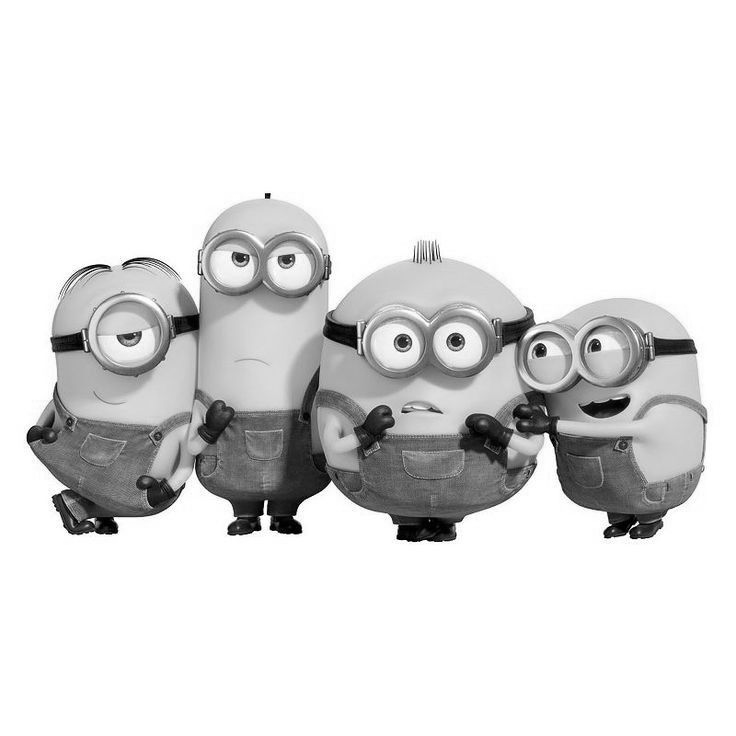

In [13]:
img_bgr = cv2.imread('minions.jpg')
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
img_grey = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img_grey

## Quantização de Imagens

Ao reduzir a quantidade de bits utilizada para representar cada pixel, a imagem passa a ter menos níveis de intensidade disponíveis. Isso reduz os detalhes e faz com que as transições entre tons fiquem mais abruptas, podendo gerar regiões com aparência mais "chapada" e efeito de posterização. Com mais bits, há mais níveis de intensidade e a imagem preserva melhor os detalhes e as transições suaves.

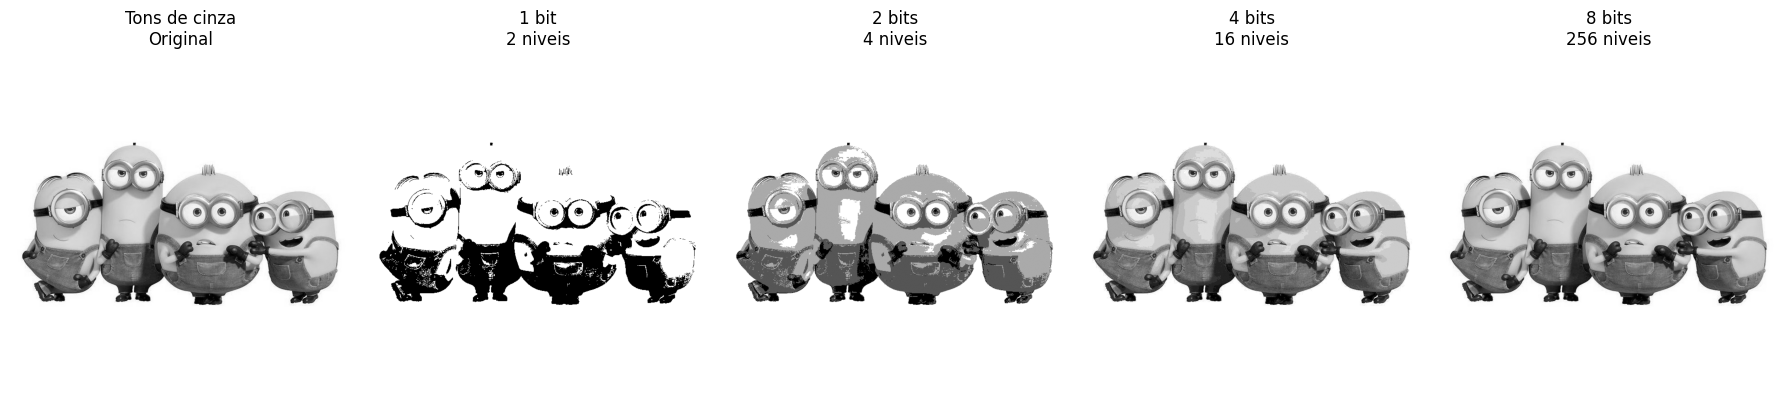

In [14]:
def quantizar(imagem, bits):
    niveis = 2 ** bits
    imagem_float = imagem.astype(np.float32)
    quantizada = np.round((imagem_float / 255) * (niveis - 1))
    quantizada = quantizada * (255 / (niveis - 1))
    return quantizada.astype(np.uint8)

img_1bit = quantizar(img_grey, 1)
img_2bits = quantizar(img_grey, 2)
img_4bits = quantizar(img_grey, 4)
img_8bits = quantizar(img_grey, 8)

fig, ax = plt.subplots(1, 5, figsize=(18, 4))

ax[0].imshow(img_grey, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Tons de cinza\nOriginal')

imagens = [img_1bit, img_2bits, img_4bits, img_8bits]
titulos = ['1 bit\n2 niveis', '2 bits\n4 niveis', '4 bits\n16 niveis', '8 bits\n256 niveis']

for i in range(4):
    ax[i + 1].imshow(imagens[i], cmap='gray', vmin=0, vmax=255)
    ax[i + 1].set_title(titulos[i])

for eixo in ax:
    eixo.axis('off')

plt.tight_layout()
plt.savefig('quantizacao.png', dpi=200, bbox_inches='tight')
plt.show()

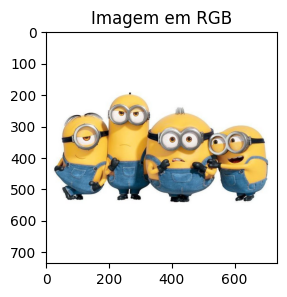

In [5]:
plt.figure(figsize=(5,3))
plt.imshow(img_rgb)
plt.title('Imagem em RGB')
plt.show()

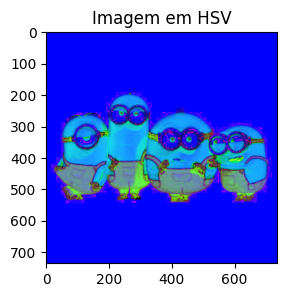

In [6]:
plt.figure(figsize=(5,3))
plt.imshow(img_hsv)
plt.title('Imagem em HSV')
plt.show()

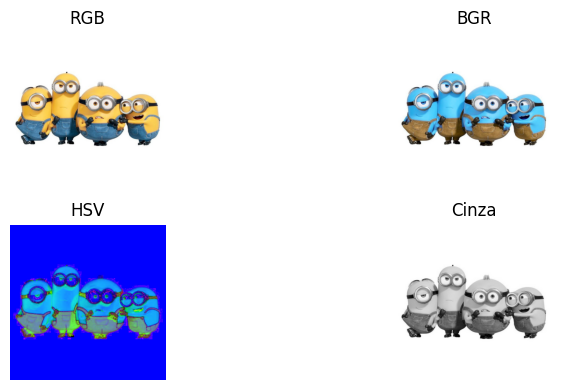

In [7]:
fig, ax = plt.subplots(2,2,figsize = (10,4))
ax[0,0].imshow(img_rgb)
ax[0,0].set_title('RGB')
ax[0,0].axis('off')

ax[0,1].imshow(img_bgr)
ax[0,1].set_title('BGR')
ax[0,1].axis('off')

ax[1,0].imshow(img_hsv)
ax[1,0].set_title('HSV')
ax[1,0].axis('off')

ax[1,1].imshow(img_grey, cmap = 'gray')
ax[1,1].set_title('Cinza')
ax[1,1].axis('off')

plt.tight_layout()
plt.savefig('bob.png')
plt.show()
